# Análisis de `resultados_kp.csv`

Este cuaderno propone un análisis del comportamiento de los métodos `sa`, `qaoa` y `qaoa_warmstart` sobre el problema de *knapsack*.

#### Hipótesis de trabajo

Dado que en este *dataset* todos los métodos alcanzan el óptimo final (`ratio_optimo = 1`, `brecha_optimo = 0`), el valor comparativo principal no está en la calidad final de la solución, sino en:

- Diferencias en el tiempo total y su descomposición.
- Probabilidad de éxito.
- Estabilidad entre ejecuciones.
- Escalabilidad con el tamaño del problema.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [3]:
df = pd.read_csv('resultados_kp.csv', na_values=['N/A'])

print('Dimensiones:', df.shape)
display(df.head())

Dimensiones: (180, 39)


,id,num_items,capacidad,num_variables_qubo,optimo,valor_total,peso,factible,coincide,ratio_optimo,brecha_optimo,exceso_peso,prob_optimo,ratio_optimo_medio,tiempo_total,t_solver,t_cuantico,t_clasico,pct_tiempo_solver_sobre_total,pct_tiempo_cuantico_sobre_solver,pct_tiempo_clasico_sobre_solver,tiempo_medio_iter,tiempo_por_eval,total_evals,num_factibles_qaoa,prob_optimo_muestras,prob_optimo_starts,tasa_factibilidad,ratio_medio_factibles,valor_medio_start,std_valor_start,tiempo_medio_start,total_muestras,starts,reads_por_start,muestras_esperadas,metodo,warmstart,epsilon_warmstart
0,201,2,5,5,9,9,5,True,True,1.0000,0,0,0.8000,0.9111,436.2139,436.2117,426.7258,9.4859,1.0000,0.9783,0.0217,0.1389,0.1738,"2,510.0000",10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,qaoa_warmstart,True,0.2500
1,202,2,6,5,11,11,6,True,True,1.0000,0,0,1.0000,1.0000,386.3198,386.3176,377.0347,9.2829,1.0000,0.9760,0.0240,0.1234,0.1539,"2,510.0000",10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,qaoa_warmstart,True,0.2500
2,203,2,5,5,8,8,5,True,True,1.0000,0,0,0.7000,0.8125,413.0037,413.0014,403.6093,9.3921,1.0000,0.9773,0.0227,0.1319,0.1645,"2,510.0000",10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,qaoa_warmstart,True,0.2500
3,204,2,4,5,6,6,4,True,True,1.0000,0,0,1.0000,1.0000,471.0047,471.0022,461.6840,9.3182,1.0000,0.9802,0.0198,0.1500,0.1877,"2,510.0000",10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,qaoa_warmstart,True,0.2500
4,301,3,5,6,9,9,5,True,True,1.0000,0,0,0.8000,0.9778,906.0691,906.0669,896.2669,9.8000,1.0000,0.9892,0.0108,0.2897,0.3610,"2,510.0000",10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,qaoa_warmstart,True,0.2500


In [4]:
display(df['metodo'].value_counts(dropna=False).rename_axis('metodo').to_frame('frecuencia')) #Número de ejecuciones con cada método

,frecuencia
metodo,
qaoa_warmstart,60
qaoa,60
sa,60


In [5]:
variables_resumen = [
    'ratio_optimo', 'brecha_optimo', 'exceso_peso', 'tiempo_total',
    'prob_optimo', 'ratio_optimo_medio', 't_solver', 't_cuantico', 't_clasico',
    'prob_optimo_muestras', 'prob_optimo_starts', 'tasa_factibilidad',
    'ratio_medio_factibles', 'valor_medio_start', 'std_valor_start',
    'tiempo_medio_start'
]
variables_resumen = [c for c in variables_resumen if c in df.columns]

tabla_descriptivos = df.groupby('metodo')[variables_resumen].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display(tabla_descriptivos) #Comparación estadística de cada método en las métricas de evaluación

ratio_optimo                                    brecha_optimo  \
                      count   mean median    std    min    max         count   
metodo                                                                         
qaoa                     60 1.0000 1.0000 0.0000 1.0000 1.0000            60   
qaoa_warmstart           60 0.9984 1.0000 0.0123 0.9048 1.0000            60   
sa                       60 1.0000 1.0000 0.0000 1.0000 1.0000            60   

                                            exceso_peso                       \
                 mean median    std min max       count   mean median    std   
metodo                                                                         
qaoa           0.0000 0.0000 0.0000   0   0          60 0.0000 0.0000 0.0000   
qaoa_warmstart 0.0333 0.0000 0.2582   0   2          60 0.0000 0.0000 0.0000   
sa             0.0000 0.0000 0.0000   0   0          60 0.0000 0.0000 0.0000   

                       tiempo_total                                          \
               min max        count       mean   median        std      min   
metodo                                                                        
qaoa             0   0           60 2,142.2956 998.5828 2,206.4924 427.3249   
qaoa_warmstart   0   0           60 1,731.2486 884.3058 1,676.7846 377.1099   
sa               0   0           60     0.0195   0.0190     0.0027   0.0156   

                          prob_optimo                                     \
                      max       count   mean median    std    min    max   
metodo                                                                     
qaoa           5,956.8392          60 0.8033 0.8500 0.1646 0.4000 1.0000   
qaoa_warmstart 4,706.2600          60 0.7533 0.8000 0.2273 0.0000 1.0000   
sa                 0.0246           0    NaN    NaN    NaN    NaN    NaN   

               ratio_optimo_medio                                    t_solver  \
                            count   mean median    std    min    max    count   
metodo                                                                          
qaoa                           60 0.9579 0.9667 0.0406 0.8000 1.0000       60   
qaoa_warmstart                 60 0.9475 0.9548 0.0515 0.7667 1.0000       60   
sa                              0    NaN    NaN    NaN    NaN    NaN        0   

                                                                  t_cuantico  \
                     mean   median        std      min        max      count   
metodo                                                                         
qaoa           2,142.2931 998.5804 2,206.4921 427.3227 5,956.8363         60   
qaoa_warmstart 1,731.2462 884.3035 1,676.7844 377.1078 4,706.2573         60   
sa                    NaN      NaN        NaN      NaN        NaN          0   

                                                                  t_clasico  \
                     mean   median        std      min        max     count   
metodo                                                                        
qaoa           2,131.3677 988.5284 2,204.3785 418.1754 5,942.4531        60   
qaoa_warmstart 1,720.5551 874.5662 1,675.0419 367.9535 4,692.6867        60   
sa                    NaN      NaN        NaN      NaN        NaN         0   

                                                    prob_optimo_muestras  \
                  mean median    std    min     max                count   
metodo                                                                     
qaoa           10.9254 9.9260 2.1305 8.8858 14.4920                    0   
qaoa_warmstart 10.6911 9.7171 1.7588 9.0580 13.9651                    0   
sa                 NaN    NaN    NaN    NaN     NaN                   60   

                                                  prob_optimo_starts         \
                 mean median    std    min    max              count   mean   
metodo                                                         

### Análisis tiempo total de ejecución
#### Análisis tiempo de ejecución por método

Aquí se realiza un análisi de la distribución de los tiempos de ejecuión por método. Se representan primero de forma individual en tiempo de cada método. Esto es especialmente necesario para poder ver la distribución de `sa`, ya que presenta tiempos de ejecución significativamente menores y, de forma agregada, no es posible ver la distribución de este método. Posteriormente, se reliza una comparación de todos los métodos.

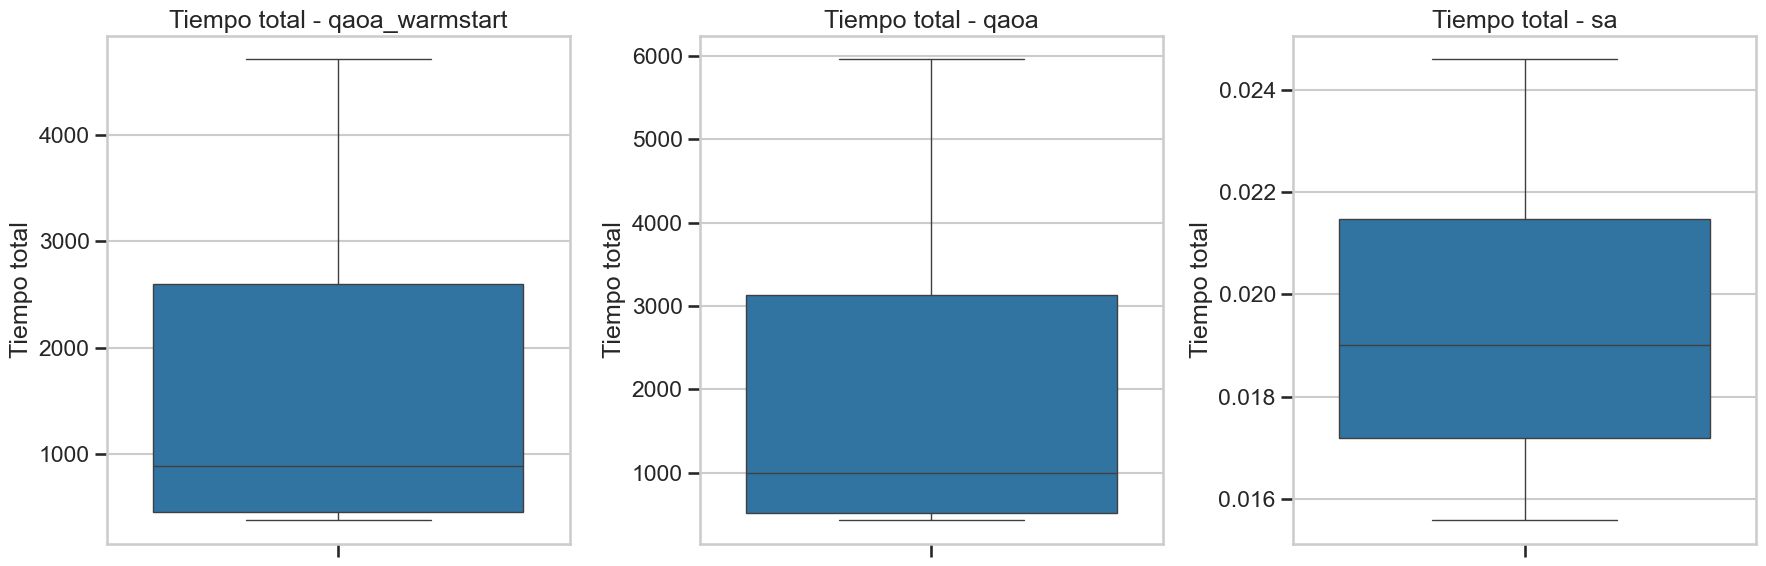

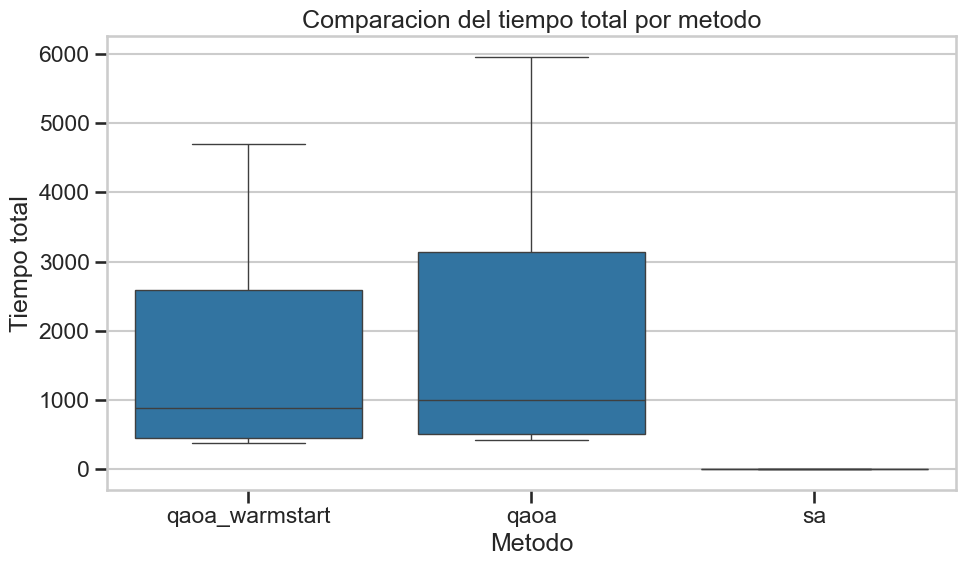

In [6]:
#Representación box-plot de cada método

metodos = df['metodo'].unique()

# ---- graficas individuales ----
fig, axes = plt.subplots(1, len(metodos), figsize=(6 * len(metodos), 6))

if len(metodos) == 1:
    axes = [axes]

for i, metodo in enumerate(metodos):
    sns.boxplot(
        data=df[df['metodo'] == metodo],
        y='tiempo_total',
        ax=axes[i],
        showfliers=True
    )
    axes[i].set_title(f'Tiempo total - {metodo}')
    axes[i].set_ylabel('Tiempo total')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


#Comparación agregada
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='metodo',
    y='tiempo_total',
    showfliers=True
)

plt.title('Comparacion del tiempo total por metodo')
plt.xlabel('Metodo')
plt.ylabel('Tiempo total')

plt.tight_layout()
plt.show()

En los gráficos se puede ver una diferenciación clara tanto entre métodos cuánticos y clásicos, como entre las ejecuciones con QAOA *warm-start* y QAOA estándar. El método SA presenta tiempos prácticamente despreciables en comparación con el resto, con una distribución muy concentrada y baja dispersión. Esto indica un comportamiento estable y consistente entre ejecuciones. En contraste, QAOA y QAOA *warm-start* operan en una escala temporal varios órdenes de magnitud superior, con distribuciones mucho más amplias y presencia de numerosos valores atípicos altos, reflejando una variabilidad significativa en el coste computacional. Entre ambos, QAOA *warm-start* muestra una  mejora respecto a QAOA puro, con una mediana inferior y una dispersión algo más contenida.

#### Análisis de escalabilidad con el tamaño del problema

En esta sección se realiza un análisis del comportamiento de los tiempos de ejecución a medida que aumenta el tamaño del problema. Para ello, se representa la mediana del tiempo total en función del número de ítems y del número de variables de la formulación QUBO. Este análisis permite evaluar cómo escala cada método conforme aumenta la complejidad de la instancia, identificando diferencias en crecimiento computacional y posibles limitaciones de escalabilidad entre los enfoques considerados.

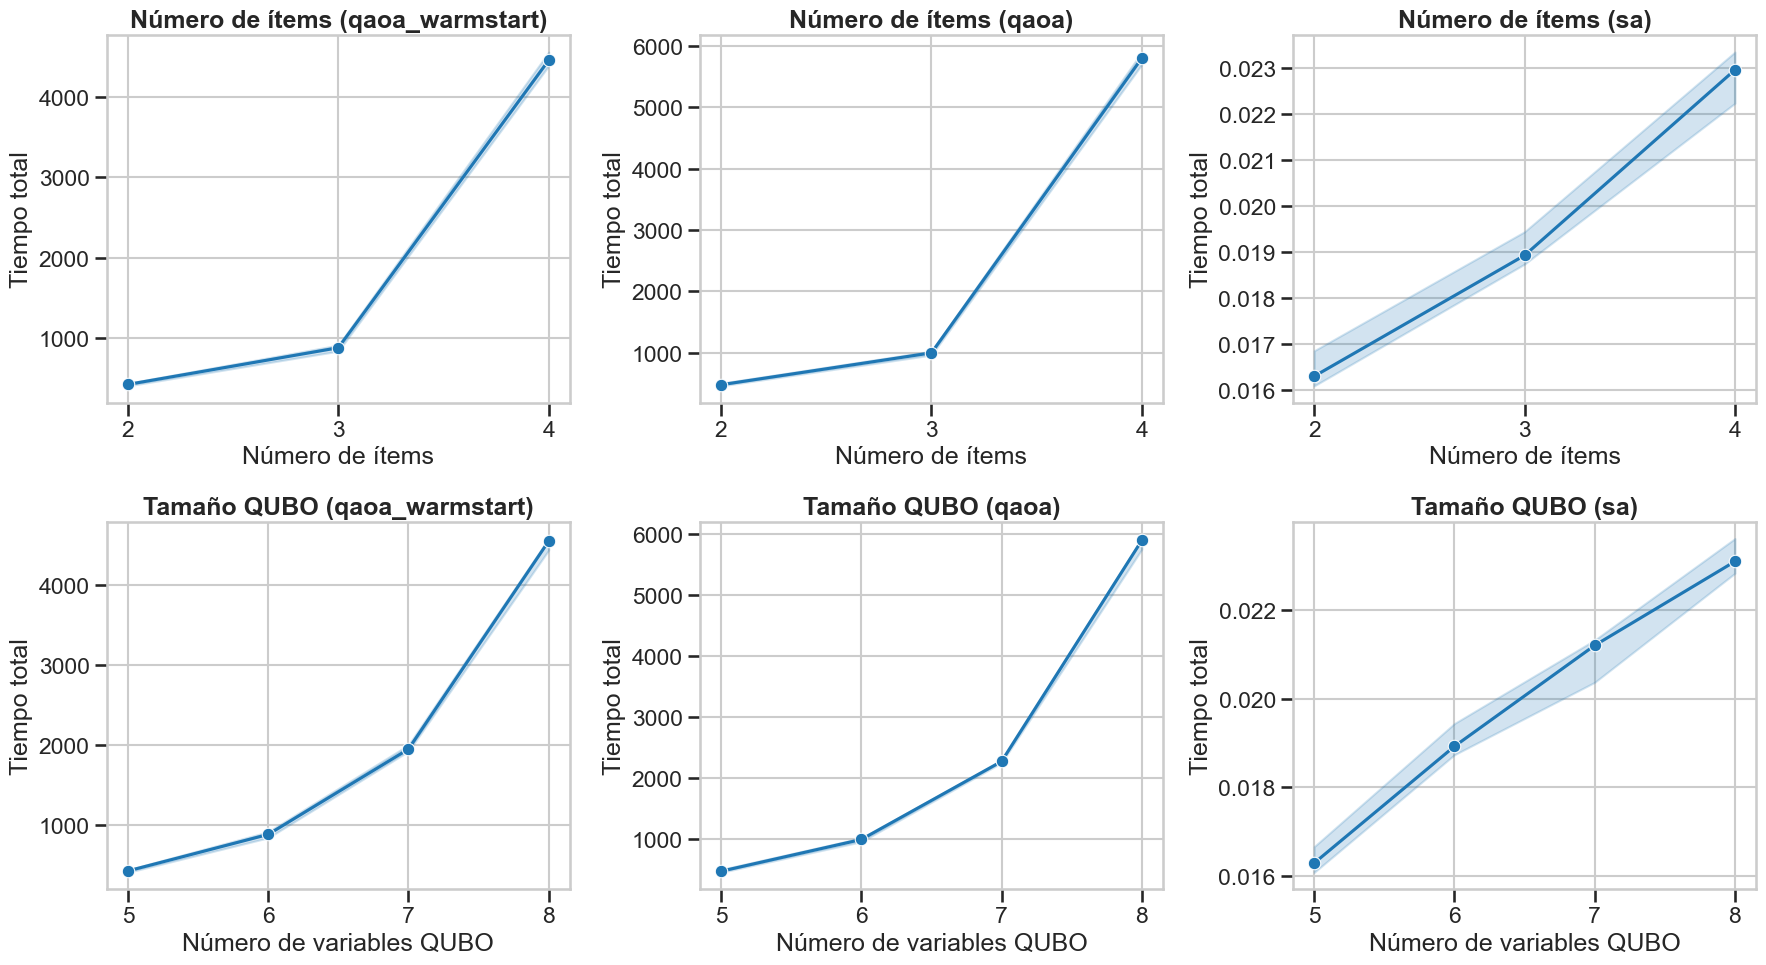

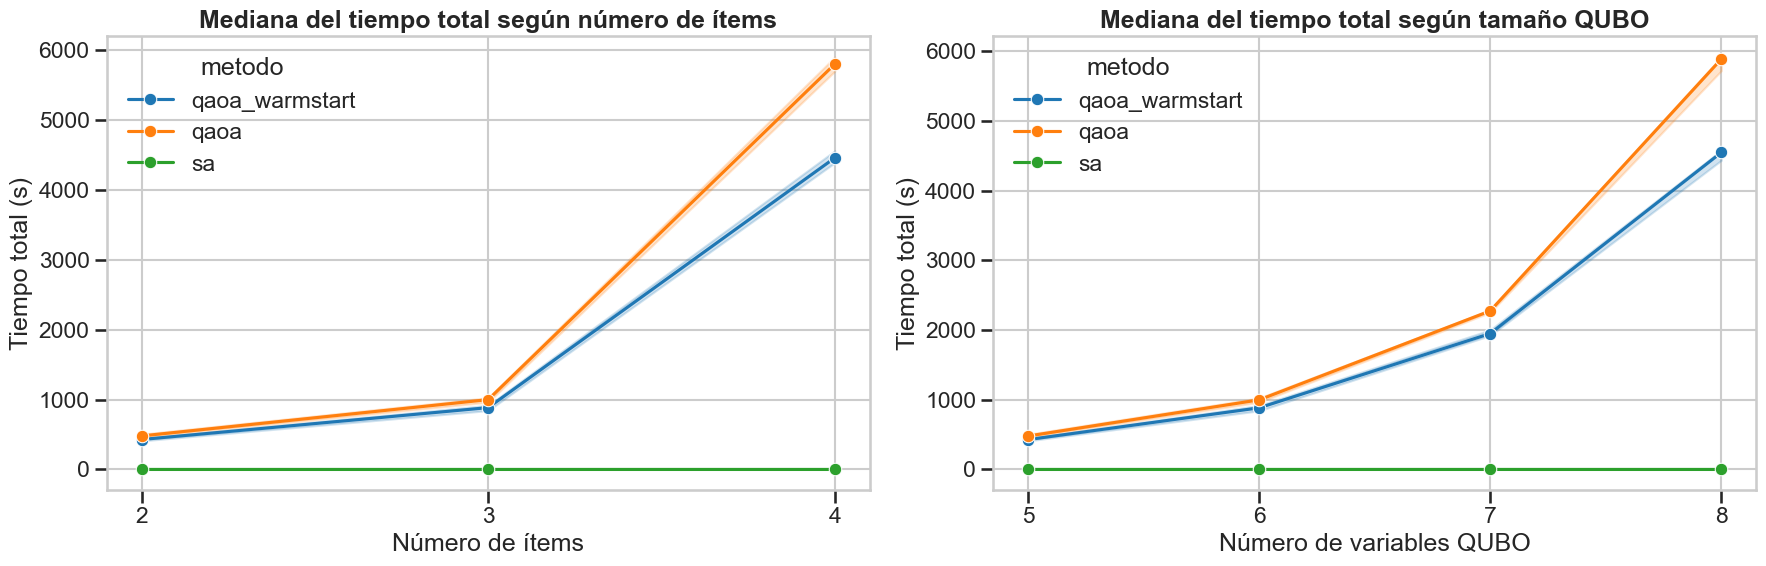

In [7]:
from matplotlib.ticker import MaxNLocator

metodos = df['metodo'].unique()

#GRÁFICOS PARA CADA MÉTODO
fig, axes = plt.subplots(2, len(metodos), figsize=(18, 10))

# Escalabilidad con número de items
for i, metodo in enumerate(metodos):
    df_metodo = df[df['metodo'] == metodo]

    sns.lineplot(
        data=df_metodo,
        x='num_items',
        y='tiempo_total',
        estimator='median',
        marker='o',
        ax=axes[0, i]
    )

    axes[0, i].set_title(
        f'Número de ítems ({metodo})',
        fontweight='bold'
    )
    axes[0, i].set_xlabel('Número de ítems')
    axes[0, i].set_ylabel('Tiempo total')
    axes[0, i].xaxis.set_major_locator(MaxNLocator(integer=True))


# Escalabilidad con tamaño del QUBO
for i, metodo in enumerate(metodos):
    df_metodo = df[df['metodo'] == metodo]

    sns.lineplot(
        data=df_metodo,
        x='num_variables_qubo',
        y='tiempo_total',
        estimator='median',
        marker='o',
        ax=axes[1, i]
    )

    axes[1, i].set_title(
        f'Tamaño QUBO ({metodo})',
        fontweight='bold'
    )
    axes[1, i].set_xlabel('Número de variables QUBO')
    axes[1, i].set_ylabel('Tiempo total')
    axes[1, i].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

#GRÁFICOS AGREGADOS
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=df,
    x='num_items',
    y='tiempo_total',
    hue='metodo',
    estimator='median',
    marker='o',
    ax=axes[0]
)

axes[0].set_title(
    'Mediana del tiempo total según número de ítems',
    fontweight='bold'
)
axes[0].set_xlabel('Número de ítems')
axes[0].set_ylabel('Tiempo total (s)')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))


sns.lineplot(
    data=df,
    x='num_variables_qubo',
    y='tiempo_total',
    hue='metodo',
    estimator='median',
    marker='o',
    ax=axes[1]
)

axes[1].set_title(
    'Mediana del tiempo total según tamaño QUBO',
    fontweight='bold'
)
axes[1].set_xlabel('Número de variables QUBO')
axes[1].set_ylabel('Tiempo total (s)')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

En los gráficos se observa un comportamiento de escalabilidad claramente diferenciado entre los enfoques clásicos y cuánticos. El método SA mantiene un crecimiento muy reducido y aproximadamente lineal tanto con el aumento del número de ítems como del tamaño de la formulación QUBO, lo que indica un comportamiento estable y una baja sensibilidad al incremento de complejidad en el rango de instancias analizado.

En contraste, QAOA y QAOA *warm-start* muestran una degradación mucho más pronunciada del rendimiento. En ambos casos, el tiempo de ejecución crece de forma no lineal, con una aceleración evidente a medida que aumenta el tamaño del problema. Esto sugiere que el coste computacional no escala de forma proporcional con la complejidad de la instancia, sino que se vuelve progresivamente más costoso conforme aumenta la dimensionalidad del espacio de búsqueda. La comparación entre ambos enfoques cuánticos muestra un patrón consistente: QAOA warm-start mantiene tiempos sistemáticamente inferiores a QAOA estándar en todas las configuraciones evaluadas. 

Además, el incremento temporal parece estar más relacionado con el tamaño de la formulación QUBO que con el número de ítems en sí, lo que sugiere que el principal cuello de botella se encuentra en la complejidad de la representación y resolución del problema dentro del esquema híbrido. En conjunto, los resultados muestran que warm-start introduce una mejora consistente sobre QAOA estándar, pero insuficiente para compensar las limitaciones de escalabilidad observadas frente al enfoque clásico.

## Decomposición temporal de QAOA y QAOA warm-start
### Descomposición mediana $t_{cuantico}$ y $t_{clasico}$

Antes de analizar las métricas de $t_{cuantico}$ y $t_{clasico}$, vamos a explicar que mide cada una específicamente.

- **$t_{cuantico}$**: Se define como `sampler.tiempo_total` en `qaoa_solver_kp.py` (line 86). El valor se acumula dentro de `TimedSamplerJob.result()` midiendo cuánto tarda `job.result()` cada vez que QAOA pide resultados al sampler, en `qaoa_solver_kp.py` (line 24). Por lo tanto, `t_cuantico` mide el tiempo consumido por las evaluaciones del sampler de Qiskit, la parte asociada a ejecutar y devolver los resultados de los circuitos de QAOA.

- **$t_{clasico}$**: Se define como $t_{solver} - t_{cuantico}$ en qaoa_solver_kp.py (line 87). $t_{solver}$ es la suma de los tiempos de cada llamada a `solver.solve(qp)` en los distintos starts, medida entre t0 y t1 en `qaoa_solver_kp.py` (line 156) y acumulada en `qaoa_solver_kp.py` (line 210). Por tanto, $t_clasico$ mide el resto del tiempo del solver que no se atribuye al sampler: optimización clásica de parámetros, lógica de MinimumEigenOptimizer o warm-start, preparación de llamadas y overhead interno. (ESTO ESTÁ MAL. CAMBIAR)


ESTO HACE FALTA CAMBIARLO PARA LA NUEVA DEFINICIÓN DE T_CLASICO


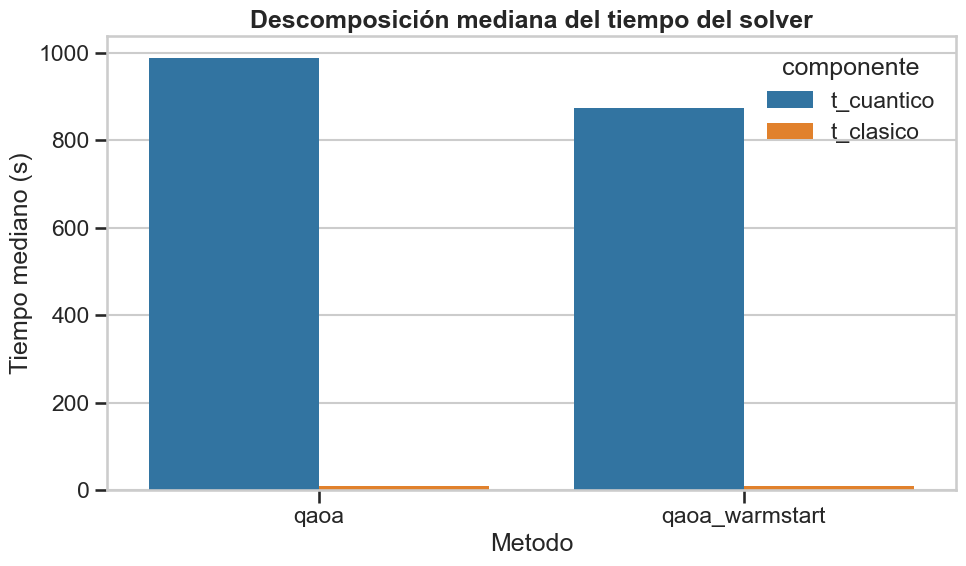

In [9]:
df_q = df[df['metodo'].isin(['qaoa', 'qaoa_warmstart'])].copy()
componentes = ['t_cuantico', 't_clasico']
comp = df_q.groupby('metodo')[componentes].median().reset_index().melt(id_vars='metodo', var_name='componente', value_name='mediana_tiempo')

plt.figure(figsize=(10, 6))
sns.barplot(data=comp, x='metodo', y='mediana_tiempo', hue='componente')
plt.title('Descomposición mediana del tiempo del solver', fontweight='bold')
plt.xlabel('Metodo')
plt.ylabel('Tiempo mediano (s)')
plt.tight_layout()
plt.show()

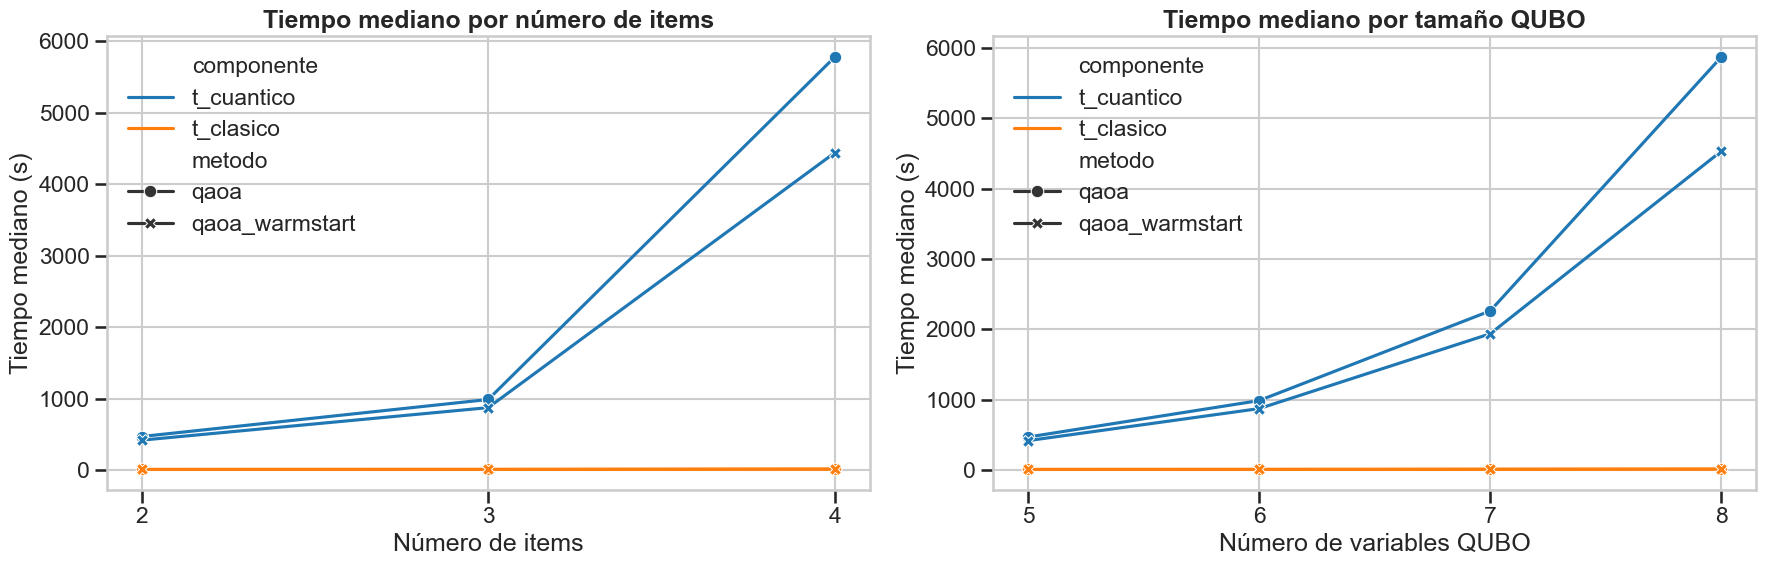

In [10]:
df_q = df[df['metodo'].isin(['qaoa', 'qaoa_warmstart'])].copy()
componentes = ['t_cuantico', 't_clasico']

comp_items = (
    df_q
    .groupby(['metodo', 'num_items'])[componentes]
    .median()
    .reset_index()
    .melt(
        id_vars=['metodo', 'num_items'],
        var_name='componente',
        value_name='mediana_tiempo'
    )
)

comp_qubo = (
    df_q
    .groupby(['metodo', 'num_variables_qubo'])[componentes]
    .median()
    .reset_index()
    .melt(
        id_vars=['metodo', 'num_variables_qubo'],
        var_name='componente',
        value_name='mediana_tiempo'
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=comp_items,
    x='num_items',
    y='mediana_tiempo',
    hue='componente',
    style='metodo',
    markers=True,
    dashes=False,
    ax=axes[0]
)
axes[0].set_title('Tiempo mediano por número de items', fontweight='bold')
axes[0].set_xlabel('Número de items')
axes[0].set_ylabel('Tiempo mediano (s)')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

sns.lineplot(
    data=comp_qubo,
    x='num_variables_qubo',
    y='mediana_tiempo',
    hue='componente',
    style='metodo',
    markers=True,
    dashes=False,
    ax=axes[1]
)
axes[1].set_title('Tiempo mediano por tamaño QUBO', fontweight='bold')
axes[1].set_xlabel('Número de variables QUBO')
axes[1].set_ylabel('Tiempo mediano (s)')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()



NO VOY A HACER EL ANALISIS TODAVIA PORQUE VA A CAMBIAR CUANDO EJECUTE DE NUEVO.

#### Análisis métricas internas específicas por familia de método

Aquí se realiza un análisis de métricas internas que son específicas de cada familia de métodos y que permiten complementar la comparación basada únicamente en tiempo de ejecución y calidad final de solución. En el caso de los métodos basados en QAOA, se analizan indicadores relacionados con la capacidad del algoritmo para alcanzar soluciones óptimas y con la calidad media de las soluciones generadas a lo largo del proceso. Para el método SA, se evalúan métricas asociadas al muestreo, como la probabilidad de obtener soluciones óptimas y la proporción de soluciones factibles generadas. Este análisis permite entender con mayor profundidad el comportamiento interno de cada enfoque y no solo su rendimiento observable final.

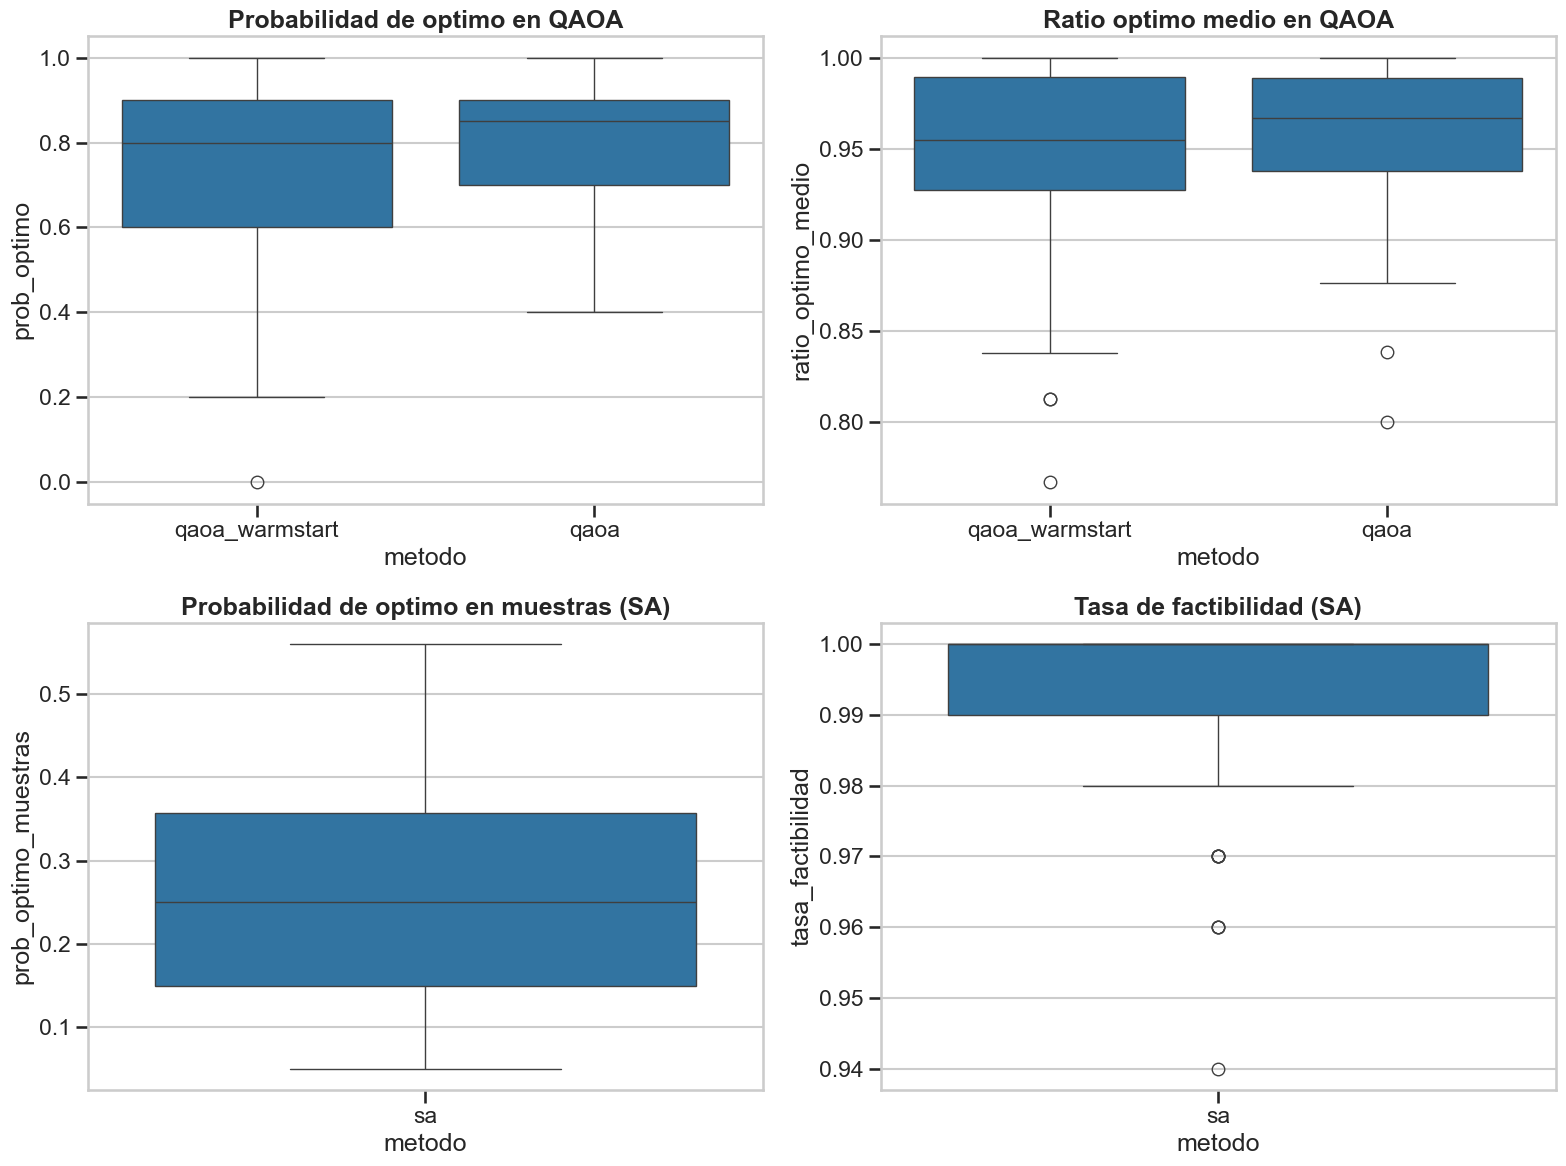

In [11]:
# Visualizacion 4: metricas internas especificas por familia de metodo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

if df['prob_optimo'].notna().any():
    sns.boxplot(data=df[df['metodo'].isin(['qaoa', 'qaoa_warmstart'])], x='metodo', y='prob_optimo', ax=axes[0, 0])
    axes[0, 0].set_title('Probabilidad de optimo en QAOA', fontweight = 'bold')
else:
    axes[0, 0].axis('off')

if df['ratio_optimo_medio'].notna().any():
    sns.boxplot(data=df[df['metodo'].isin(['qaoa', 'qaoa_warmstart'])], x='metodo', y='ratio_optimo_medio', ax=axes[0, 1])
    axes[0, 1].set_title('Ratio optimo medio en QAOA', fontweight = 'bold')
else:
    axes[0, 1].axis('off')

if df['prob_optimo_muestras'].notna().any():
    sns.boxplot(data=df[df['metodo'] == 'sa'], x='metodo', y='prob_optimo_muestras', ax=axes[1, 0])
    axes[1, 0].set_title('Probabilidad de optimo en muestras (SA)', fontweight = 'bold')
else:
    axes[1, 0].axis('off')

if df['tasa_factibilidad'].notna().any():
    sns.boxplot(data=df[df['metodo'] == 'sa'], x='metodo', y='tasa_factibilidad', ax=axes[1, 1])
    axes[1, 1].set_title('Tasa de factibilidad (SA)', fontweight = 'bold')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


En el caso de los enfoques basados en QAOA, tanto la probabilidad de alcanzar la solución óptima como el ratio óptimo medio presentan valores elevados y distribuciones muy similares entre QAOA estándar y QAOA *warm-start*. Esto sugiere que ambos métodos mantienen una capacidad comparable para encontrar soluciones de alta calidad, sin que la mejora temporal observada previamente en *warm-start* implique una ganancia significativa en calidad de solución. La principal diferencia entre ambos parece concentrarse en eficiencia computacional más que en rendimiento de optimización.

El análisis del ratio óptimo medio refuerza esta conclusión. Ambos métodos muestran medianas muy próximas a 1 y una dispersión reducida, lo que indica un comportamiento consistentemente cercano al óptimo incluso cuando no se alcanza la mejor solución exacta. La presencia de algunos valores atípicos más bajos evidencia cierta sensibilidad en determinadas ejecuciones, probablemente asociada a dificultades de convergencia o a variabilidad en el proceso de optimización paramétrica, pero estos casos no alteran el patrón general de alto rendimiento.

En el caso de SA, las métricas reflejan un comportamiento distinto. La probabilidad de encontrar la solución óptima dentro del conjunto de muestras es considerablemente más moderada y presenta una dispersión apreciable, lo que indica que el óptimo no aparece de forma dominante en el muestreo. Sin embargo, esto no implica necesariamente un peor rendimiento práctico, ya que SA ya había mostrado tiempos de ejecución muy inferiores y una alta estabilidad temporal. Es decir, aunque individualmente cada muestra tenga menor probabilidad de ser óptima, el bajo coste computacional del método permite compensar esta limitación mediante una exploración rápida y repetida del espacio de soluciones.

La tasa de factibilidad en SA se mantiene cercana a 1 en la mayoría de ejecuciones, lo que indica que el método genera predominantemente soluciones válidas y respeta de forma consistente las restricciones del problema. Aunque aparecen algunos valores atípicos con menor factibilidad, estos son minoritarios y no modifican el comportamiento general. 

En conjunto, los resultados muestran que mientras QAOA concentra su fortaleza en la calidad sistemática de las soluciones generadas, SA destaca por eficiencia y robustez operativa, manteniendo además un alto nivel de factibilidad.

## Contraste estadístico

In [12]:
columnas_base = ['id', 'num_items', 'capacidad', 'num_variables_qubo', 'optimo']
df['instancia_clave'] = df[columnas_base].astype(str).agg(' | '.join, axis=1)

def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    return diff.mean() / diff.std(ddof=1)

comparables = df[df['metodo'].isin(['qaoa', 'qaoa_warmstart'])].copy()
agg = comparables.groupby(['instancia_clave', 'metodo'], as_index=False).agg({
    'tiempo_total': 'median',
    'prob_optimo': 'median',
    'ratio_optimo_medio': 'median',
    't_cuantico': 'median',
    't_clasico': 'median'
})

pivot_t = agg.pivot(index='instancia_clave', columns='metodo', values='tiempo_total').dropna()
pivot_p = agg.pivot(index='instancia_clave', columns='metodo', values='prob_optimo').dropna()

resultados = []

for nombre, tabla in [('tiempo_total', pivot_t), ('prob_optimo', pivot_p)]:
    x = tabla['qaoa']
    y = tabla['qaoa_warmstart']
    diff = x - y
    shapiro_p = stats.shapiro(diff).pvalue if len(diff) >= 3 else np.nan
    if pd.notna(shapiro_p) and shapiro_p > 0.05:
        test_name = 't-test apareado'
        pvalue = stats.ttest_rel(x, y).pvalue
    else:
        test_name = 'Wilcoxon'
        pvalue = stats.wilcoxon(x, y).pvalue
    resultados.append({
        'variable': nombre,
        'n_pares': len(tabla),
        'mediana_qaoa': np.median(x),
        'mediana_qaoa_warmstart': np.median(y),
        'shapiro_p_diferencias': shapiro_p,
        'prueba': test_name,
        'p_valor': pvalue,
        'cohens_d_paired': cohens_d_paired(x, y)
    })

display(pd.DataFrame(resultados))

,variable,n_pares,mediana_qaoa,mediana_qaoa_warmstart,shapiro_p_diferencias,prueba,p_valor,cohens_d_paired
0,tiempo_total,12,989.2352,883.7177,0.0002,Wilcoxon,0.0005,0.7393
1,prob_optimo,12,0.8500,0.8000,0.0152,Wilcoxon,0.2500,0.4628


El contraste estadístico entre QAOA y QAOA *warm-start* muestra con bastante claridad que la diferencia principal entre ambos métodos está en el tiempo de ejecución, no en la calidad de las soluciones. Por un lado, QAOA *warm-start* presenta una mediana de tiempo total menor que QAOA, y esta diferencia resulta estadísticamente significativa en la prueba de Wilcoxon. Esto indica que la reducción de tiempo no parece deberse al azar, sino a un comportamiento sistemático del método. Además, el tamaño del efecto es alto, lo que refuerza la idea de que la mejora temporal es importante también desde un punto de vista práctico. Por otro lado, al analizar la probabilidad de alcanzar la solución óptima, ambos métodos muestran prácticamente el mismo comportamiento: las medianas son iguales y la prueba estadística no encuentra diferencias significativas entre ellos. En consecuencia, los resultados sugieren que el uso de warm-start no hace que QAOA encuentre mejores soluciones ni que aumente de forma clara su probabilidad de éxito, pero sí permite llegar a resultados equivalentes en menos tiempo. En este sentido, la ventaja de QAOA *warm-start* debe interpretarse sobre todo como una mejora de eficiencia computacional, mientras que la calidad final de la solución se mantiene esencialmente estable respecto a QAOA estándar.

## Correlaciones entre complejidad y coste computacional

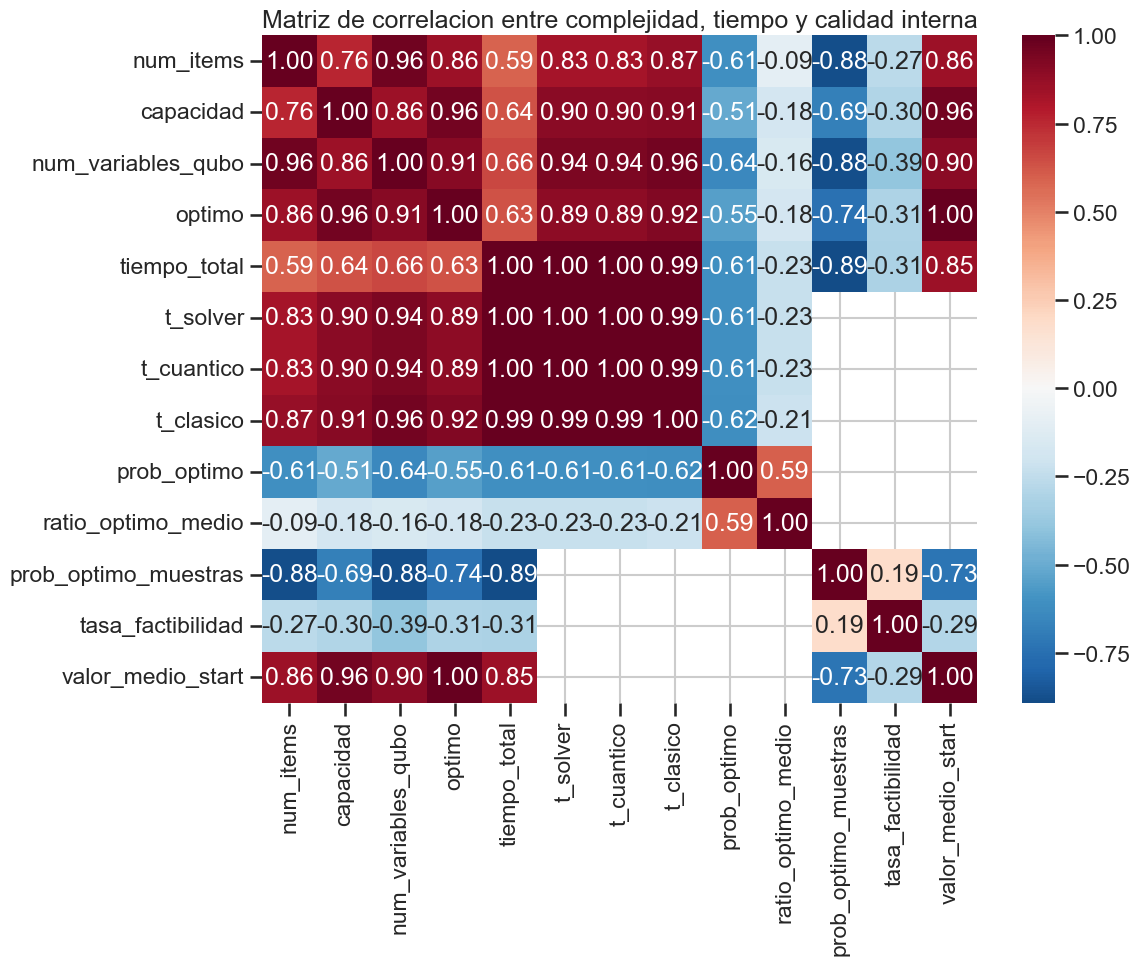

In [13]:
# Correlaciones entre complejidad y coste computacional
cols_corr = [
    'num_items', 'capacidad', 'num_variables_qubo', 'optimo',
    'tiempo_total', 't_solver', 't_cuantico', 't_clasico',
    'prob_optimo', 'ratio_optimo_medio', 'prob_optimo_muestras',
    'tasa_factibilidad', 'valor_medio_start'
]
cols_corr = [c for c in cols_corr if c in df.columns]
corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matriz de correlacion entre complejidad, tiempo y calidad interna')
plt.tight_layout()
plt.show()

ESTO HAY QUE ANALIZARLO CON LOS NUEVOS RESULTADOS.